# Updated: fixed-level Fibonacci interaction analysis

This notebook includes breakout, pullback, and combined event-frequency comparisons across original, random synthetic, and trained synthetic paths. The implementation is in `fibonacci_state_detection.py`; the three fixed-level histograms are in the final notebook section.

In [1]:
from read_valid_samples import load_valid_samples_npz   
from fibonacci_state_detection import (
    EventType, InteractionState, detect_fibonacci_interactions,
)
import numpy as np

from amgm.utils.common import calculate_fibLevels

import matplotlib.pyplot as plt


In [2]:
from pathlib import Path

def resolve_workspace_npz(relative_npz_path):
    """Resolve a workspace-relative NPZ path from the current notebook environment."""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        resolved = candidate / relative_npz_path
        if resolved.exists():
            return resolved
    raise FileNotFoundError(
        f'Could not find {relative_npz_path} from {current} or any parent directory'
    )

npz_path = resolve_workspace_npz(
    Path('Data/Synthetic/synthetic_rollout_MC_valid_samples.npz')
)

loaded_samples = load_valid_samples_npz(str(npz_path), mode="MC")

In [3]:
import pandas as pd

mc_sample_index = pd.DataFrame([
    {
        'issue_id': str(sample['issue_id']),
        'test_date': str(sample['test_date']),
        'base_sample_id': sample['base_sample_id'],
        'path_id': sample['path_id'],
        'mc_iteration': sample['mc_iteration'],
        'is_valid': bool(sample['is_valid']),
    }
    for sample in loaded_samples['samples']
])

mc_paths_by_issue_date = (
    mc_sample_index.groupby(['issue_id', 'test_date'], as_index=False)
    .agg(
        mc_path_count=('path_id', 'size'),
        distinct_mc_iterations=('mc_iteration', 'nunique'),
        valid_mc_path_count=('is_valid', 'sum'),
    )
    .sort_values(['issue_id', 'test_date'])
    .reset_index(drop=True)
)

number_of_issue_ids = mc_sample_index['issue_id'].nunique()
number_of_issue_date_samples = len(mc_paths_by_issue_date)
number_of_mc_paths = len(mc_sample_index)

print(f'Number of distinct issue IDs: {number_of_issue_ids}')
print(f'Total number of issue-ID/date samples: {number_of_issue_date_samples}')
print(f'Total number of loaded MC paths: {number_of_mc_paths}')
print('\nMC paths for each issue-ID/date:')
display(mc_paths_by_issue_date)


Number of distinct issue IDs: 41
Total number of issue-ID/date samples: 500
Total number of loaded MC paths: 10000

MC paths for each issue-ID/date:


,issue_id,test_date,mc_path_count,distinct_mc_iterations,valid_mc_path_count
0,00170601,2016-08-08,20,20,20
1,00170601,2016-08-17,20,20,20
2,00170601,2016-08-25,20,20,20
3,00170601,2016-10-17,20,20,20
4,00170601,2017-02-23,20,20,20
...,...,...,...,...,...
495,18749001,2016-11-25,20,20,20
496,18749001,2017-03-21,20,20,20
497,18749001,2017-04-18,20,20,20
498,18749001,2017-11-01,20,20,20


In [4]:
loaded_samples['samples'][0].keys()

dict_keys(['issue_id', 'test_date', 'hist', 'price_min', 'price_range', 'fib_levels', 'original_price', 'synthetic_path', 'path_id', 'base_sample_id', 'mc_iteration', 'is_valid', 'master_seed'])

In [5]:
loaded_samples['samples'][10]['fib_levels']


array([0.   , 0.236, 0.382, 0.5  , 0.618, 0.786, 1.   ], dtype=float32)

In [6]:
def historical_scale(seed_window_normalized, price_min, price_range):
    """Recover real history and define its fixed min-max normalization."""
    history_real = np.asarray(seed_window_normalized, dtype=np.float32).reshape(-1) * price_range + price_min
    history_min = float(np.min(history_real))
    history_range = max(float(np.max(history_real) - history_min), 1e-8)
    history_scaled = (history_real - history_min) / history_range
    return history_real, history_scaled, history_min, history_range

def normalize_real_prices(prices, history_min, history_range):
    """Normalize real prices using only the historical period's scale."""
    return (np.asarray(prices, dtype=np.float32).reshape(-1) - history_min) / history_range

def mean_normalized_fixed_fibonacci_distance(history_real, rollout_real):
    """Mean future distance to Fibonacci levels frozen at the history endpoint.

    Both the rollout and the fixed levels are normalized with the minimum and
    range of the complete historical window. The future does not update either
    the normalization scale or the Fibonacci levels.
    """
    history_real = np.asarray(history_real, dtype=np.float32).reshape(-1)
    rollout_real = np.asarray(rollout_real, dtype=np.float32).reshape(-1)
    rollout_real = rollout_real[np.isfinite(rollout_real)]
    if history_real.size == 0 or not np.all(np.isfinite(history_real)):
        raise ValueError('history_real must contain only finite values')
    if rollout_real.size < 2:
        raise ValueError('rollout_real must contain its starting point and at least one future point')
    if not np.isclose(rollout_real[0], history_real[-1], rtol=1e-5, atol=1e-6):
        raise ValueError('rollout_real[0] must equal history_real[-1]')

    history_min = float(np.min(history_real))
    history_range = max(float(np.max(history_real) - history_min), 1e-8)
    fixed_levels_real, _ = calculate_fibLevels(history_real[None, :])
    fixed_levels_normalized = (fixed_levels_real[0] - history_min) / history_range
    future_normalized = normalize_real_prices(rollout_real[1:], history_min, history_range)
    nearest_distances = np.min(
        np.abs(future_normalized[:, None] - fixed_levels_normalized[None, :]), axis=1
    )
    return float(np.mean(nearest_distances)), nearest_distances, fixed_levels_normalized

# Fixed Vasicek parameters in historical normalized-price units.
VASICEK_KAPPA = 0.015 # 0.15
VASICEK_MU = 0.50
VASICEK_SIGMA = 0.015 # 0.05
VASICEK_DT = 1.0
VASICEK_SEED = 20260805

def simulate_vasicek_path(x0, path_length, rng, kappa, mu, sigma, dt=1.0):
    """Draw a Vasicek path using fixed parameters and an explicit start."""
    if path_length < 1:
        raise ValueError('path_length must be positive')
    if kappa <= 0 or sigma < 0 or dt <= 0:
        raise ValueError('kappa and dt must be positive, and sigma non-negative')
    phi = np.exp(-kappa * dt)
    step_std = sigma * np.sqrt((1.0 - phi ** 2) / (2.0 * kappa))
    path = np.empty(path_length, dtype=np.float32)
    path[0] = x0
    for step in range(1, path_length):
        conditional_mean = mu + (path[step - 1] - mu) * phi
        path[step] = conditional_mean + step_std * rng.standard_normal()
    return path

# Add one independent, reproducible fixed-parameter baseline to every sample.
vasicek_seed_sequences = np.random.SeedSequence(VASICEK_SEED).spawn(
    len(loaded_samples['samples'])
)
for sample, seed_sequence in zip(loaded_samples['samples'], vasicek_seed_sequences):
    _, sample_history_normalized, sample_history_min, sample_history_range = historical_scale(
        sample['hist'], sample['price_min'], sample['price_range']
    )
    random_synthetic_normalized = simulate_vasicek_path(
        x0=sample_history_normalized[-1],
        path_length=len(sample['synthetic_path']),
        rng=np.random.default_rng(seed_sequence),
        kappa=VASICEK_KAPPA,
        mu=VASICEK_MU,
        sigma=VASICEK_SIGMA,
        dt=VASICEK_DT,
    )
    sample['random_synthetic'] = (
        random_synthetic_normalized * sample_history_range + sample_history_min
    ).astype(np.float32)


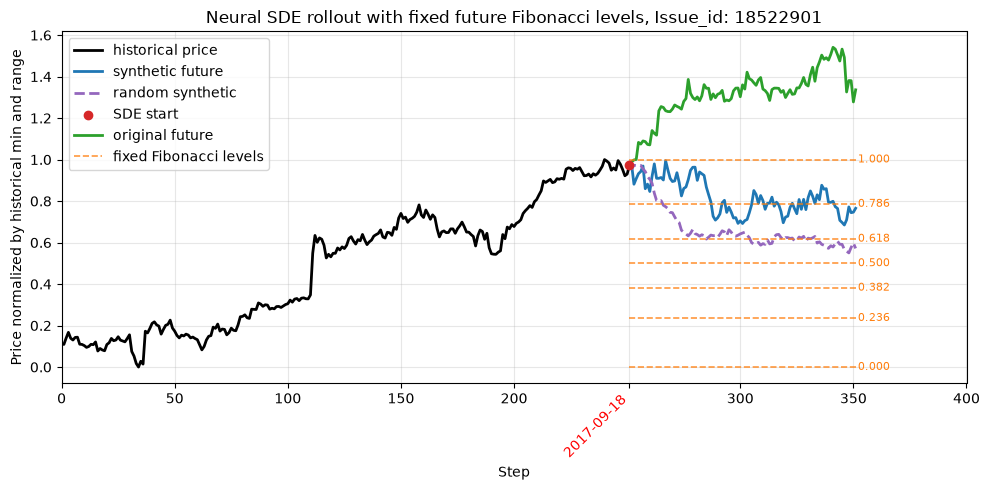

In [7]:
# Extract the first sample
sample_idx = 0
sample = loaded_samples['samples'][sample_idx]

synthetic_path_real = np.asarray(sample['synthetic_path'], dtype=np.float32)
original_price_real = np.asarray(sample['original_price'], dtype=np.float32)
random_synthetic_real = np.asarray(sample['random_synthetic'], dtype=np.float32)
hist_normalized = sample['hist']
price_min = sample['price_min']
price_range = sample['price_range']

# First invert the dataset transformation to recover real historical prices.
# Then apply one fixed normalization defined only by that historical period.
hist_real, hist, history_min, history_range = historical_scale(
    hist_normalized, price_min, price_range
)
synthetic_path = normalize_real_prices(synthetic_path_real, history_min, history_range)
original_price = normalize_real_prices(original_price_real, history_min, history_range)
random_synthetic = normalize_real_prices(random_synthetic_real, history_min, history_range)
fib_levels_real, _ = calculate_fibLevels(hist_real[None, :])
fib_levels = (fib_levels_real[0] - history_min) / history_range

test_date = sample['test_date']
issue_id = sample['issue_id']
hist_idx = np.arange(len(hist))
fut_idx = np.arange(len(hist) - 1, len(hist) - 1 + len(synthetic_path))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist_idx, hist, label='historical price', color='black', linewidth=2)
ax.plot(fut_idx, synthetic_path, label='synthetic future', color='tab:blue', linewidth=2)
ax.plot(
    fut_idx, random_synthetic, label='random synthetic', color='tab:purple',
    linewidth=2, linestyle='--',
)
ax.scatter([fut_idx[0]], [synthetic_path[0]], color='tab:red', zorder=5, label='SDE start')

original_price = np.asarray(original_price)
original_price_len = min(len(fut_idx), len(original_price))
if original_price_len > 0:
    ax.plot(
        fut_idx[:original_price_len],
        original_price[:original_price_len],
        label='original future',
        color='tab:green',
        linewidth=2,
    )

ax.set_xlim(left=0)
current_ticks = ax.get_xticks()
positive_ticks = current_ticks[current_ticks >= 0]
if len(positive_ticks) > 1:
    tick_spacing = float(np.min(np.diff(positive_ticks)))
    min_distance_to_test_date = tick_spacing * 0.5
    filtered_ticks = positive_ticks[np.abs(positive_ticks - fut_idx[0]) > min_distance_to_test_date]
else:
    filtered_ticks = positive_ticks
custom_ticks = np.unique(np.append(filtered_ticks, fut_idx[0]))
custom_labels = [
    str(test_date) if np.isclose(tick, fut_idx[0]) else f'{int(round(tick))}'
    for tick in custom_ticks
]
ax.set_xticks(custom_ticks)
ax.set_xticklabels(custom_labels)
for tick, label in zip(custom_ticks, ax.get_xticklabels()):
    if np.isclose(tick, fut_idx[0]):
        label.set_rotation(45)
        label.set_horizontalalignment('right')
        label.set_color('red')

fib_names = ['0.000', '0.236', '0.382', '0.500', '0.618', '0.786', '1.000']
for level_idx, (level, name) in enumerate(zip(fib_levels, fib_names)):
    ax.hlines(
        level, fut_idx[0], fut_idx[-1], colors='tab:orange', linestyles='--',
        linewidth=1.2, alpha=0.8,
        label='fixed Fibonacci levels' if level_idx == 0 else None,
    )
    ax.text(fut_idx[-1] + 1, level, name, color='tab:orange', va='center', fontsize=8)
ax.set_xlabel('Step')
ax.set_ylabel('Price normalized by historical min and range')
ax.set_title(f'Neural SDE rollout with fixed future Fibonacci levels, Issue_id: {issue_id}')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# Volatility

In [8]:
import pandas as pd

def summarize_mc_metrics(frame, group_columns, metric_columns):
    """Summarize valid path-level metrics across MC realizations."""
    rows = []
    for group_key, group in frame.groupby(group_columns, sort=True, dropna=False):
        group_key = group_key if isinstance(group_key, tuple) else (group_key,)
        row = dict(zip(group_columns, group_key))
        row['mc_path_count'] = len(group)
        row['valid_mc_path_count'] = int(group['is_valid'].sum())
        for metric in metric_columns:
            values = group.loc[group['is_valid'], metric].to_numpy(dtype=float)
            values = values[np.isfinite(values)]
            row[f'{metric}_mean'] = np.mean(values) if values.size else np.nan
            row[f'{metric}_std'] = np.std(values, ddof=0) if values.size else np.nan
            row[f'{metric}_q05'] = np.quantile(values, 0.05) if values.size else np.nan
            row[f'{metric}_median'] = np.median(values) if values.size else np.nan
            row[f'{metric}_q95'] = np.quantile(values, 0.95) if values.size else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

# Rebuild the fixed-Fibonacci path metrics used by the later paired analysis.
fib_records = []
for sample in loaded_samples['samples']:
    history_real, _, _, _ = historical_scale(
        sample['hist'], sample['price_min'], sample['price_range']
    )
    synthetic_distance, _, _ = mean_normalized_fixed_fibonacci_distance(
        history_real, sample['synthetic_path']
    )
    original_distance, _, _ = mean_normalized_fixed_fibonacci_distance(
        history_real, sample['original_price']
    )
    fib_records.append({
        'issue_id': sample['issue_id'],
        'test_date': sample['test_date'],
        'base_sample_id': sample['base_sample_id'],
        'path_id': sample['path_id'],
        'mc_iteration': sample['mc_iteration'],
        'is_valid': sample['is_valid'],
        'synthetic_fib_distance': synthetic_distance,
        'original_fib_distance': original_distance,
        'synthetic_to_original_ratio': (
            synthetic_distance / original_distance if original_distance > 0 else np.nan
        ),
    })

fib_path_metrics = pd.DataFrame(fib_records)

def price_delta_statistics(price_series, scale=1.0):
    """Return summary statistics of consecutive price changes.

    Delta is defined as ``price[t] - price[t - 1]``. Set ``scale`` to the
    seed-window price range to obtain dimensionless statistics that are
    comparable across issue IDs.
    """
    prices = np.asarray(price_series, dtype=float).reshape(-1)
    prices = prices[np.isfinite(prices)]
    scale = float(scale)

    if prices.size < 2:
        raise ValueError('price_series must contain at least two finite prices')
    if not np.isfinite(scale) or scale <= 0:
        raise ValueError('scale must be finite and strictly positive')

    deltas = np.diff(prices) / scale
    return {
        'count': deltas.size,
        'mean': np.mean(deltas),
        'std': np.std(deltas, ddof=0),
        'median': np.median(deltas),
        'mean_abs': np.mean(np.abs(deltas)),
        'rms': np.sqrt(np.mean(deltas ** 2)),
        'min': np.min(deltas),
        'q05': np.quantile(deltas, 0.05),
        'q25': np.quantile(deltas, 0.25),
        'q75': np.quantile(deltas, 0.75),
        'q95': np.quantile(deltas, 0.95),
        'max': np.max(deltas),
        'positive_fraction': np.mean(deltas > 0),
        'negative_fraction': np.mean(deltas < 0),
    }

# Build one normalized delta-statistics record per MC path. Synthetic and
# original paths both begin at hist[-1], so np.diff covers future transitions.
delta_records = []
delta_stat_names = [
    'mean', 'std', 'median', 'mean_abs', 'rms',
    'min', 'q05', 'q25', 'q75', 'q95', 'max',
    'positive_fraction', 'negative_fraction',
]

for sample in loaded_samples['samples']:
    price_range = sample['price_range']
    hist = sample['hist'] * price_range + sample['price_min']
    source_stats = {
        'history': price_delta_statistics(hist, scale=price_range),
        'synthetic': price_delta_statistics(
            sample['synthetic_path'], scale=price_range
        ),
        'original': price_delta_statistics(
            sample['original_price'], scale=price_range
        ),
    }
    record = {
        'issue_id': sample['issue_id'],
        'test_date': sample['test_date'],
        'base_sample_id': sample['base_sample_id'],
        'path_id': sample['path_id'],
        'mc_iteration': sample['mc_iteration'],
        'is_valid': sample['is_valid'],
    }
    for source, stats in source_stats.items():
        for stat_name in delta_stat_names:
            record[f'{source}_{stat_name}'] = stats[stat_name]
    delta_records.append(record)

delta_path_metrics = pd.DataFrame(delta_records)
delta_metric_columns = [
    f'{source}_{stat_name}'
    for source in ('history', 'synthetic', 'original')
    for stat_name in delta_stat_names
]
delta_by_issue_date = summarize_mc_metrics(
    delta_path_metrics,
    ['issue_id', 'test_date', 'base_sample_id'],
    delta_metric_columns,
)
delta_by_issue = summarize_mc_metrics(
    delta_path_metrics,
    ['issue_id'],
    delta_metric_columns,
)

# Compact volatility comparison: standard deviation, mean absolute delta,
# and RMS delta. Full quantile/statistic tables remain in the variables above.
volatility_columns = [
    'issue_id', 'mc_path_count', 'valid_mc_path_count',
    *[
        f'{source}_{stat}_{aggregation}'
        for source in ('history', 'synthetic', 'original')
        for stat in ('std', 'mean_abs', 'rms')
        for aggregation in ('mean', 'std', 'q05', 'median', 'q95')
    ],
]
display(delta_by_issue[volatility_columns].head(5))
delta_by_issue_date.head(5)

,issue_id,mc_path_count,valid_mc_path_count,history_std_mean,history_std_std,history_std_q05,history_std_median,history_std_q95,history_mean_abs_mean,history_mean_abs_std,...,original_mean_abs_mean,original_mean_abs_std,original_mean_abs_q05,original_mean_abs_median,original_mean_abs_q95,original_rms_mean,original_rms_std,original_rms_q05,original_rms_median,original_rms_q95
0,00170601,240,240,0.061424,0.006741,0.055547,0.060294,0.082631,0.045576,0.005127,...,0.042509,0.006293,0.034979,0.040909,0.052625,0.057813,0.008556,0.045535,0.058836,0.068494
1,00549201,240,240,0.047221,0.014043,0.026934,0.050824,0.064799,0.033422,0.009830,...,0.030685,0.005778,0.018788,0.033128,0.037526,0.043123,0.009216,0.025117,0.046824,0.051642
2,00591801,260,260,0.041835,0.008883,0.028135,0.039635,0.065395,0.031484,0.007082,...,0.032194,0.005361,0.024081,0.032568,0.045238,0.043776,0.007207,0.029387,0.045532,0.059843
3,00694601,240,240,0.038092,0.006459,0.031902,0.036343,0.051576,0.028089,0.004878,...,0.027971,0.010584,0.017910,0.022152,0.048404,0.038446,0.013805,0.023452,0.030339,0.064082
4,00792201,240,239,0.038800,0.007267,0.030479,0.039007,0.052327,0.026141,0.005813,...,0.024763,0.005532,0.017870,0.023544,0.036267,0.034796,0.007661,0.023222,0.033973,0.046806


,issue_id,test_date,base_sample_id,mc_path_count,valid_mc_path_count,history_mean_mean,history_mean_std,history_mean_q05,history_mean_median,history_mean_q95,...,original_positive_fraction_mean,original_positive_fraction_std,original_positive_fraction_q05,original_positive_fraction_median,original_positive_fraction_q95,original_negative_fraction_mean,original_negative_fraction_std,original_negative_fraction_q05,original_negative_fraction_median,original_negative_fraction_q95
0,00170601,2016-08-08,8,20,20,0.000152,0.000000e+00,0.000152,0.000152,0.000152,...,0.47,5.551115e-17,0.47,0.47,0.47,0.47,5.551115e-17,0.47,0.47,0.47
1,00170601,2016-08-17,418,20,20,0.000672,0.000000e+00,0.000672,0.000672,0.000672,...,0.47,5.551115e-17,0.47,0.47,0.47,0.47,5.551115e-17,0.47,0.47,0.47
2,00170601,2016-08-25,459,20,20,0.001443,4.336809e-19,0.001443,0.001443,0.001443,...,0.48,1.110223e-16,0.48,0.48,0.48,0.46,1.110223e-16,0.46,0.46,0.46
3,00170601,2016-10-17,213,20,20,0.000744,1.084202e-19,0.000744,0.000744,0.000744,...,0.48,1.110223e-16,0.48,0.48,0.48,0.44,5.551115e-17,0.44,0.44,0.44
4,00170601,2017-02-23,49,20,20,0.001759,2.168404e-19,0.001759,0.001759,0.001759,...,0.47,5.551115e-17,0.47,0.47,0.47,0.49,5.551115e-17,0.49,0.49,0.49


# Fibonacci interaction state detection

The same deterministic state machine is applied to the original future, trained synthetic future, and fixed-parameter random synthetic future. Breakout and pullback labels depend on which side the price approached from. Timeouts are retained for diagnostics but excluded from evaluated event proportions.

,source,hover_count,breakout_count,pullback_count,timeout_count,mean_breakout_fraction,mean_pullback_fraction,mean_breakout_to_pullback_ratio
0,original,11980,3240,13120,3680,0.206345,0.793655,0.256852
1,random synthetic,23653,6035,10118,9376,0.387863,0.612137,0.451906
2,trained synthetic,9416,2734,15374,2585,0.152815,0.847185,0.185527


findfont: Failed to find font weight semibold, now using 700.


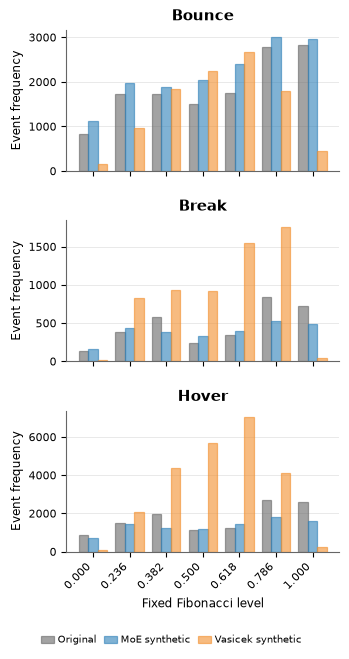

In [9]:
FIB_INTERACTION_TOLERANCE = 0.02
FIB_MIN_DWELL_STEPS = 3
FIB_CONFIRMATION_STEPS = 10
FIB_MAX_DWELL_STEPS = 20
FIB_LEVEL_LABELS = ['0.000', '0.236', '0.382', '0.500', '0.618', '0.786', '1.000']
FIB_SOURCE_ORDER = ['original', 'random synthetic', 'trained synthetic']

fibonacci_event_records = []
fibonacci_interaction_records = []

for sample in loaded_samples['samples']:
    history_real, _, history_min, history_range = historical_scale(
        sample['hist'], sample['price_min'], sample['price_range']
    )
    levels_real, _ = calculate_fibLevels(history_real[None, :])
    levels_normalized = (levels_real[0] - history_min) / history_range
    series_by_source = {
        'original': normalize_real_prices(
            sample['original_price'], history_min, history_range
        ),
        'trained synthetic': normalize_real_prices(
            sample['synthetic_path'], history_min, history_range
        ),
        'random synthetic': normalize_real_prices(
            sample['random_synthetic'], history_min, history_range
        ),
    }

    metadata = {
        'issue_id': sample['issue_id'],
        'test_date': sample['test_date'],
        'base_sample_id': sample['base_sample_id'],
        'path_id': sample['path_id'],
        'mc_iteration': sample['mc_iteration'],
        'is_valid': sample['is_valid'],
    }
    for source, prices in series_by_source.items():
        events = detect_fibonacci_interactions(
            prices,
            levels_normalized,
            tolerance=FIB_INTERACTION_TOLERANCE,
            min_dwell_steps=FIB_MIN_DWELL_STEPS,
            confirmation_steps=FIB_CONFIRMATION_STEPS,
            max_dwell_steps=FIB_MAX_DWELL_STEPS,
        )
        event_counts = {
            event_type: sum(event['event_type'] is event_type for event in events)
            for event_type in EventType
        }
        evaluated_count = (
            event_counts[EventType.BREAKOUT] + event_counts[EventType.PULLBACK]
        )
        fibonacci_interaction_records.append({
            **metadata,
            'source': source,
            'hover_count': event_counts[EventType.HOVER],
            'breakout_count': event_counts[EventType.BREAKOUT],
            'pullback_count': event_counts[EventType.PULLBACK],
            'timeout_count': event_counts[EventType.TIMEOUT],
            'evaluated_event_count': evaluated_count,
            'breakout_fraction': (
                event_counts[EventType.BREAKOUT] / evaluated_count
                if evaluated_count else np.nan
            ),
            'pullback_fraction': (
                event_counts[EventType.PULLBACK] / evaluated_count
                if evaluated_count else np.nan
            ),
            'breakout_to_pullback_ratio': (
                event_counts[EventType.BREAKOUT] / event_counts[EventType.PULLBACK]
                if event_counts[EventType.PULLBACK] else np.nan
            ),
        })
        for event in events:
            fib_level_index = int(np.argmin(
                np.abs(levels_normalized - event['fib_level'])
            ))
            fibonacci_event_records.append({
                **metadata,
                'source': source,
                **event,
                'event_type': event['event_type'].value,
                'fib_level_index': fib_level_index,
                'fib_level_label': FIB_LEVEL_LABELS[fib_level_index],
            })

fibonacci_interactions = pd.DataFrame(fibonacci_interaction_records)
fibonacci_events = pd.DataFrame(fibonacci_event_records)

fibonacci_source_summary = (
    fibonacci_interactions.groupby('source', as_index=False)
    .agg(
        hover_count=('hover_count', 'sum'),
        breakout_count=('breakout_count', 'sum'),
        pullback_count=('pullback_count', 'sum'),
        timeout_count=('timeout_count', 'sum'),
        mean_breakout_fraction=('breakout_fraction', 'mean'),
        mean_pullback_fraction=('pullback_fraction', 'mean'),
        mean_breakout_to_pullback_ratio=('breakout_to_pullback_ratio', 'mean'),
    )
)
display(fibonacci_source_summary)

def fibonacci_event_counts(events, event_types):
    """Return fixed-level event frequencies for all three price sources."""
    selected = events[events['event_type'].isin(event_types)]
    counts = (
        selected.groupby(['fib_level_label', 'source']).size()
        .reindex(
            pd.MultiIndex.from_product(
                [FIB_LEVEL_LABELS, FIB_SOURCE_ORDER],
                names=['fib_level_label', 'source'],
            ),
            fill_value=0,
        )
        .unstack('source')
        .reindex(index=FIB_LEVEL_LABELS, columns=FIB_SOURCE_ORDER)
    )
    return counts

pullback_frequency_by_level = fibonacci_event_counts(
    fibonacci_events,
    [EventType.PULLBACK.value],
)
breakout_frequency_by_level = fibonacci_event_counts(
    fibonacci_events,
    [EventType.BREAKOUT.value],
)
hover_frequency_by_level = fibonacci_event_counts(
    fibonacci_events,
    [EventType.HOVER.value],
)

# Publication figure: original, trained synthetic, then random synthetic.
from pathlib import Path

publication_histograms = [
    ('Bounce', pullback_frequency_by_level),
    ('Break', breakout_frequency_by_level),
    ('Hover', hover_frequency_by_level),
]
publication_sources = ['original', 'trained synthetic', 'random synthetic']
publication_colors = {
    'original': '#666666',
    'trained synthetic': '#2C7FB8',
    'random synthetic': '#F28E2B',
}
publication_labels = {
    'original': 'Original',
    'trained synthetic': 'MoE synthetic',
    'random synthetic': 'Vasicek synthetic',
}

# Sized for one column in a double-column paper (approximately 3.5 in wide).
fig, axes = plt.subplots(3, 1, figsize=(3.5, 6.4), sharex=True)
x_positions = np.arange(len(FIB_LEVEL_LABELS))
bar_width = 0.26
for ax, (event_name, counts) in zip(axes, publication_histograms):
    for source_index, source in enumerate(publication_sources):
        offset = (source_index - 1.0) * bar_width
        ax.bar(
            x_positions + offset,
            counts[source].to_numpy(),
            width=bar_width,
            label='_nolegend_',
            color=publication_colors[source],
            alpha=0.60,
            edgecolor=publication_colors[source],
            linewidth=0.9,
        )
    ax.set_title(event_name, loc='center', fontsize=10.5, fontweight='semibold', pad=7)
    ax.set_ylabel('Event frequency', fontsize=8.5)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', color='#D9D9D9', linewidth=0.5, alpha=0.8)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#666666')
    ax.spines['bottom'].set_color('#666666')

axes[-1].set_xticks(x_positions)
axes[-1].set_xticklabels(FIB_LEVEL_LABELS, rotation=45, ha='right', fontsize=8)
axes[-1].set_xlabel('Fixed Fibonacci level', fontsize=8.5)
from matplotlib.patches import Patch
histogram_bar_handles = [
    Patch(
        facecolor=publication_colors[source],
        edgecolor=publication_colors[source], linewidth=0.9, alpha=0.60,
        label=publication_labels[source],
    )
    for source in publication_sources
]
fig.legend(
    handles=histogram_bar_handles, title='',
    loc='lower center', ncol=3, frameon=False,
    bbox_to_anchor=(0.5, 0.005), fontsize=7.2, title_fontsize=7.8,
    handlelength=1.3, handletextpad=0.4, columnspacing=0.7,
)
fig.subplots_adjust(top=0.98, bottom=0.165, left=0.20, right=0.98, hspace=0.35)

cwd = Path.cwd().resolve()
notebook_candidates = [cwd] + [
    parent / 'experiments' / 'neural_SDE'
    for parent in (cwd, *cwd.parents)
]
notebook_dir = next(
    candidate for candidate in notebook_candidates
    if (candidate / 'Statistical_comparison.ipynb').exists()
)
fibonacci_histogram_figure_path = (
    notebook_dir / 'fibonacci_interaction_histograms_3x1.png'
)
fig.savefig(
    fibonacci_histogram_figure_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()


## Jensen–Shannon distance between event histograms

Each seven-level count histogram is normalized to a probability distribution before comparison. The base-2 Jensen–Shannon distance is bounded between 0 and 1: 0 means identical level distributions and larger values mean greater separation. The table compares both synthetic sources with the original distribution for pullback, breakout, and hover outputs.

In [10]:
from scipy.spatial.distance import jensenshannon

def jensen_shannon_histogram_metrics(count_table, reference_source, compared_source):
    """Return base-2 JS distance/divergence for two count histograms."""
    reference_counts = count_table[reference_source].to_numpy(dtype=float)
    compared_counts = count_table[compared_source].to_numpy(dtype=float)
    reference_total = reference_counts.sum()
    compared_total = compared_counts.sum()
    if reference_total == 0 or compared_total == 0:
        return {
            'js_distance': np.nan,
            'js_divergence': np.nan,
            'reference_event_count': int(reference_total),
            'compared_event_count': int(compared_total),
        }
    reference_probability = reference_counts / reference_total
    compared_probability = compared_counts / compared_total
    js_distance = float(jensenshannon(
        reference_probability, compared_probability, base=2.0
    ))
    return {
        'js_distance': js_distance,
        'js_divergence': js_distance ** 2,
        'reference_event_count': int(reference_total),
        'compared_event_count': int(compared_total),
    }

event_histograms = {
    'pullback': pullback_frequency_by_level,
    'breakout': breakout_frequency_by_level,
    'hover': hover_frequency_by_level,
}
js_records = []
for event_type, count_table in event_histograms.items():
    for compared_source in ('random synthetic', 'trained synthetic'):
        js_records.append({
            'event_type': event_type,
            'reference_source': 'original',
            'compared_source': compared_source,
            **jensen_shannon_histogram_metrics(
                count_table, 'original', compared_source
            ),
        })

fibonacci_js_distances = pd.DataFrame(js_records)

fibonacci_js_distance_table = (
    fibonacci_js_distances.pivot(
        index='event_type', columns='compared_source', values='js_distance'
    )
    .reindex(['pullback', 'breakout', 'hover'])
    .reindex(columns=['trained synthetic', 'random synthetic'])
    .rename(
        index=str.title,
        columns={
            'trained synthetic': 'Original vs. trained synthetic',
            'random synthetic': 'Original vs. random synthetic',
        },
    )
    .rename_axis('Event type')
)
display(
    fibonacci_js_distance_table.style
    .format('{:.4f}')
    .set_caption('Base-2 Jensen–Shannon distance between Fibonacci-level distributions')
)


compared_source,Original vs. trained synthetic,Original vs. random synthetic
Event type,,
Pullback,0.0464,0.2989
Breakout,0.1290,0.3753
Hover,0.1071,0.4193


## Five-sample event and state diagnostics

Print detailed events and compact lifecycle-state runs for five distinct base samples. Assertions verify that confirmed events occur after consolidation, are unique, and do not overlap.

In [11]:
def compact_state_runs(state_trace, output_annotations=None):
    """Compress states while retaining HOVER and terminal output annotations."""
    if not state_trace:
        return []
    output_annotations = output_annotations or {}
    runs = []
    run_start = 0
    for index in range(1, len(state_trace) + 1):
        if index == len(state_trace) or state_trace[index] != state_trace[run_start]:
            runs.append({
                'state': state_trace[run_start].value,
                'start_index': run_start,
                'end_index': index - 1,
                'steps': index - run_start,
                'outputs': '; '.join(
                    f'{output_index}: {output_annotations[output_index]}'
                    for output_index in range(run_start, index)
                    if output_index in output_annotations
                ),
            })
            run_start = index
    return runs

def validate_detected_outputs(outputs, state_trace):
    """Validate one HOVER and one terminal output per interaction."""
    output_keys = [
        (output['fib_level'], output['entry_index'], output['output_index'], output['event_type'])
        for output in outputs
    ]
    assert len(output_keys) == len(set(output_keys)), 'Duplicate output detected'
    assert [output['output_index'] for output in outputs] == sorted(
        output['output_index'] for output in outputs
    ), 'Outputs are not chronological'

    interactions = {}
    for output in outputs:
        key = (output['fib_level'], output['entry_index'])
        interactions.setdefault(key, []).append(output)
        expected_state = (
            InteractionState.FINISHED
            if output['is_terminal']
            else InteractionState.CONSOLIDATING
        )
        assert state_trace[output['output_index']] is expected_state

    previous_terminal_index = -1
    for interaction_outputs in interactions.values():
        hovers = [o for o in interaction_outputs if o['event_type'] is EventType.HOVER]
        terminals = [o for o in interaction_outputs if o['is_terminal']]
        assert len(hovers) <= 1, 'Interaction emitted HOVER more than once'
        assert len(terminals) <= 1, 'Interaction emitted multiple terminal outputs'
        if not terminals:
            continue
        terminal = terminals[0]
        assert terminal['entry_index'] > previous_terminal_index, 'Overlapping interactions detected'
        previous_terminal_index = terminal['output_index']
        if terminal['pullback_stage'] == 'approaching':
            assert terminal['event_type'] is EventType.PULLBACK
            assert not hovers and terminal['hover_index'] is None
        else:
            assert len(hovers) == 1, 'Consolidated terminal output has no HOVER'
            assert hovers[0]['output_index'] < terminal['output_index']

# Select five distinct base samples rather than five MC paths of the same base.
diagnostic_samples = []
seen_base_sample_ids = set()
for candidate in loaded_samples['samples']:
    if candidate['base_sample_id'] not in seen_base_sample_ids:
        diagnostic_samples.append(candidate)
        seen_base_sample_ids.add(candidate['base_sample_id'])
    if len(diagnostic_samples) == 5:
        break

for diagnostic_number, sample in enumerate(diagnostic_samples, start=1):
    history_real, _, history_min, history_range = historical_scale(
        sample['hist'], sample['price_min'], sample['price_range']
    )
    levels_real, _ = calculate_fibLevels(history_real[None, :])
    levels_normalized = (levels_real[0] - history_min) / history_range
    series_by_source = {
        'original': normalize_real_prices(
            sample['original_price'], history_min, history_range
        ),
        'random synthetic': normalize_real_prices(
            sample['random_synthetic'], history_min, history_range
        ),
        'trained synthetic': normalize_real_prices(
            sample['synthetic_path'], history_min, history_range
        ),
    }

    print('\n' + '=' * 100)
    print(
        f"SAMPLE {diagnostic_number}: issue_id={sample['issue_id']}, "
        f"test_date={sample['test_date']}, base_sample_id={sample['base_sample_id']}"
    )
    print('Fixed Fibonacci levels:', dict(zip(FIB_LEVEL_LABELS, levels_normalized)))

    for source, prices in series_by_source.items():
        outputs, state_trace = detect_fibonacci_interactions(
            prices,
            levels_normalized,
            tolerance=FIB_INTERACTION_TOLERANCE,
            min_dwell_steps=FIB_MIN_DWELL_STEPS,
            confirmation_steps=FIB_CONFIRMATION_STEPS,
            max_dwell_steps=FIB_MAX_DWELL_STEPS,
            return_state_trace=True,
        )
        validate_detected_outputs(outputs, state_trace)

        printable_outputs = []
        output_annotations = {}
        for output in outputs:
            level_index = int(np.argmin(np.abs(levels_normalized - output['fib_level'])))
            output_annotations[output['output_index']] = (
                f"{output['event_type'].value.upper()} at Fibonacci "
                f"{FIB_LEVEL_LABELS[level_index]}"
            )
            printable_outputs.append({
                'output_index': output['output_index'],
                'state': state_trace[output['output_index']].value,
                'event_type': output['event_type'].value,
                'fib_level': FIB_LEVEL_LABELS[level_index],
                'entry_index': output['entry_index'],
                'hover_index': output['hover_index'],
                'exit_index': output['exit_index'],
                'confirmation_end_index': output['confirmation_end_index'],
                'pullback_stage': output['pullback_stage'],
                'approach_direction': output['approach_direction'],
                'exit_direction': output['exit_direction'],
                'dwell_time': output['dwell_time'],
            })

        print(f'\nSOURCE: {source}')
        print('CHRONOLOGICAL OUTPUTS:')
        if printable_outputs:
            print(pd.DataFrame(printable_outputs).to_string(index=False))
        else:
            print('No outputs')
        print('STATE RUNS:')
        print(
            pd.DataFrame(
                compact_state_runs(state_trace, output_annotations)
            ).to_string(index=False)
        )
        print('Validation: HOVER and terminal outputs are unique, ordered, and non-overlapping.')



SAMPLE 1: issue_id=18522901, test_date=2017-09-18, base_sample_id=0
Fixed Fibonacci levels: {'0.000': np.float32(0.0), '0.236': np.float32(0.23600002), '0.382': np.float32(0.382), '0.500': np.float32(0.4999999), '0.618': np.float32(0.61800003), '0.786': np.float32(0.7860001), '1.000': np.float32(1.0)}

SOURCE: original
CHRONOLOGICAL OUTPUTS:
 output_index         state event_type fib_level  entry_index  hover_index  exit_index  confirmation_end_index pullback_stage approach_direction exit_direction  dwell_time
            3 consolidating      hover     1.000            1            3         NaN                     NaN           None                 up            NaN           3
           13      finished   breakout     1.000            1            3         4.0                    13.0           None                 up             up           3
STATE RUNS:
        state  start_index  end_index  steps                         outputs
         idle            0          0      1      

# Daily-return distribution for one issue/date

For one forecast origin, compare (1) the original path's mean daily return with the distribution of path-level mean daily returns from the trained Neural SDE and Vasicek ensembles, and (2) the original path's daily-return distribution with the pooled daily returns from all valid trained and Vasicek paths. Returns are simple returns, $P_t/P_{t-1}-1$; paths include the common forecast-origin price, so the first return is the transition from the origin to the first future value. Change the two selector variables below to inspect another issue/date.

In [12]:
# Select one issue/date. The defaults choose the first available valid pair.
valid_sample_index = mc_sample_index.loc[mc_sample_index['is_valid']].reset_index(drop=True)
if valid_sample_index.empty:
    raise ValueError('No valid trained MC paths are available')
RETURN_ISSUE_ID = valid_sample_index.loc[0, 'issue_id']
RETURN_TEST_DATE = valid_sample_index.loc[0, 'test_date']

def simple_daily_returns(prices):
    """Return finite simple returns for a one-dimensional price path."""
    prices = np.asarray(prices, dtype=float).reshape(-1)
    if prices.size < 2:
        raise ValueError('A price path must contain at least two observations')
    previous = prices[:-1]
    current = prices[1:]
    valid = np.isfinite(previous) & np.isfinite(current) & (previous != 0)
    returns = current[valid] / previous[valid] - 1.0
    if returns.size == 0:
        raise ValueError('The price path has no finite daily returns')
    return returns

ROLLING_VOLATILITY_WINDOW = 20

def rolling_daily_volatility(returns, window=ROLLING_VOLATILITY_WINDOW):
    """Rolling population standard deviation of daily returns."""
    returns = np.asarray(returns, dtype=float).reshape(-1)
    returns = returns[np.isfinite(returns)]
    if window < 2:
        raise ValueError('window must be at least 2')
    if returns.size < window:
        return np.empty(0, dtype=float)
    return np.array([
        returns[end - window:end].std(ddof=0)
        for end in range(window, returns.size + 1)
    ])

def maximum_drawdown(prices):
    """Return the largest peak-to-trough loss as a positive fraction."""
    prices = np.asarray(prices, dtype=float).reshape(-1)
    prices = prices[np.isfinite(prices)]
    if prices.size == 0:
        raise ValueError('A price path must contain at least one finite observation')
    running_peak = np.maximum.accumulate(prices)
    valid = running_peak > 0
    if not np.any(valid):
        raise ValueError('Maximum drawdown requires at least one positive running peak')
    drawdowns = (running_peak[valid] - prices[valid]) / running_peak[valid]
    return float(np.max(np.maximum(drawdowns, 0.0)))

selected_samples = [
    sample for sample in loaded_samples['samples']
    if str(sample['issue_id']) == str(RETURN_ISSUE_ID)
    and str(sample['test_date']) == str(RETURN_TEST_DATE)
]
if not selected_samples:
    available_pairs = mc_paths_by_issue_date[['issue_id', 'test_date']].head(10)
    raise ValueError(
        f'No samples found for issue_id={RETURN_ISSUE_ID!r}, '
        f'test_date={RETURN_TEST_DATE!r}. Example available pairs:\n{available_pairs}'
    )

valid_trained_samples = [sample for sample in selected_samples if sample['is_valid']]
if not valid_trained_samples:
    raise ValueError('The selected issue/date has no valid trained MC paths')

# The original future is repeated for every MC realization; use it once.
original_returns = simple_daily_returns(selected_samples[0]['original_price'])
trained_returns_by_path = [
    simple_daily_returns(sample['synthetic_path']) for sample in valid_trained_samples
]
# Keep the Vasicek ensemble paired with the same valid MC records.
vasicek_returns_by_path = [
    simple_daily_returns(sample['random_synthetic']) for sample in valid_trained_samples
]

original_mean_daily_return = float(np.mean(original_returns))
trained_mean_daily_returns = np.array([returns.mean() for returns in trained_returns_by_path])
vasicek_mean_daily_returns = np.array([returns.mean() for returns in vasicek_returns_by_path])
original_daily_volatility = float(np.std(original_returns, ddof=0))
trained_daily_volatilities = np.array([
    returns.std(ddof=0) for returns in trained_returns_by_path
])
vasicek_daily_volatilities = np.array([
    returns.std(ddof=0) for returns in vasicek_returns_by_path
])
original_rolling_volatilities = rolling_daily_volatility(original_returns)
all_trained_rolling_volatilities = np.concatenate([
    rolling_daily_volatility(returns) for returns in trained_returns_by_path
])
all_vasicek_rolling_volatilities = np.concatenate([
    rolling_daily_volatility(returns) for returns in vasicek_returns_by_path
])
original_maximum_drawdown = maximum_drawdown(selected_samples[0]['original_price'])
trained_maximum_drawdowns = np.array([
    maximum_drawdown(sample['synthetic_path']) for sample in valid_trained_samples
])
vasicek_maximum_drawdowns = np.array([
    maximum_drawdown(sample['random_synthetic']) for sample in valid_trained_samples
])
all_trained_daily_returns = np.concatenate(trained_returns_by_path)
all_vasicek_daily_returns = np.concatenate(vasicek_returns_by_path)

return_summary = pd.DataFrame({
    'source': ['Original', 'Trained MC', 'Vasicek MC'],
    'path_count': [1, len(trained_returns_by_path), len(vasicek_returns_by_path)],
    'daily_return_count': [
        original_returns.size, all_trained_daily_returns.size, all_vasicek_daily_returns.size
    ],
    'mean_daily_return': [
        original_mean_daily_return, all_trained_daily_returns.mean(), all_vasicek_daily_returns.mean()
    ],
    'daily_return_std': [
        original_returns.std(ddof=0),
        all_trained_daily_returns.std(ddof=0),
        all_vasicek_daily_returns.std(ddof=0),
    ],
    'maximum_drawdown': [
        original_maximum_drawdown, trained_maximum_drawdowns.mean(),
        vasicek_maximum_drawdowns.mean(),
    ],
})
print(f'Issue ID: {RETURN_ISSUE_ID} | Test date: {RETURN_TEST_DATE}')
display(return_summary.style.format({
    'mean_daily_return': '{:.4%}', 'daily_return_std': '{:.4%}',
    'maximum_drawdown': '{:.4%}'
}))


Issue ID: 18522901 | Test date: 2017-09-18


,source,path_count,daily_return_count,mean_daily_return,daily_return_std,maximum_drawdown
0,Original,1,100,0.1234%,1.1741%,7.4710%
1,Trained MC,20,2000,0.0575%,1.8428%,17.6482%
2,Vasicek MC,20,2000,-0.1241%,0.5671%,13.6532%


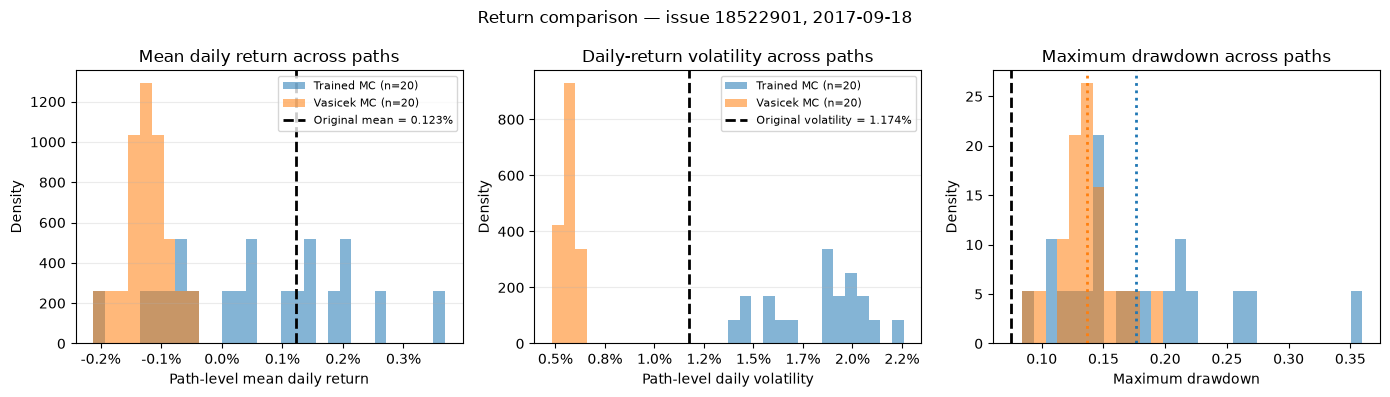

In [13]:
def shared_histogram_edges(*arrays, bins=40):
    """Create common finite histogram bins, including degenerate inputs."""
    values = np.concatenate([np.asarray(array, dtype=float).reshape(-1) for array in arrays])
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise ValueError('No finite values are available for the histogram')
    low, high = values.min(), values.max()
    if np.isclose(low, high):
        padding = max(abs(low) * 0.05, 1e-8)
        low, high = low - padding, high + padding
    return np.linspace(low, high, bins + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.ravel()

mean_edges = shared_histogram_edges(
    trained_mean_daily_returns, vasicek_mean_daily_returns,
    np.array([original_mean_daily_return]), bins=30,
)
axes[0].hist(
    trained_mean_daily_returns, bins=mean_edges, density=True, alpha=0.55,
    color='tab:blue', label=f'Trained MC (n={len(trained_mean_daily_returns)})',
)
axes[0].hist(
    vasicek_mean_daily_returns, bins=mean_edges, density=True, alpha=0.55,
    color='tab:orange', label=f'Vasicek MC (n={len(vasicek_mean_daily_returns)})',
)
axes[0].axvline(
    original_mean_daily_return, color='black', linestyle='--', linewidth=2,
    label=f'Original mean = {original_mean_daily_return:.3%}',
)
axes[0].set(
    title='Mean daily return across paths',
    xlabel='Path-level mean daily return', ylabel='Density',
)



volatility_edges = shared_histogram_edges(
    trained_daily_volatilities, vasicek_daily_volatilities,
    np.array([original_daily_volatility]), bins=30,
)
axes[1].hist(
    trained_daily_volatilities, bins=volatility_edges, density=True, alpha=0.55,
    color='tab:blue', label=f'Trained MC (n={len(trained_daily_volatilities)})',
)
axes[1].hist(
    vasicek_daily_volatilities, bins=volatility_edges, density=True, alpha=0.55,
    color='tab:orange', label=f'Vasicek MC (n={len(vasicek_daily_volatilities)})',
)
axes[1].axvline(
    original_daily_volatility, color='black', linestyle='--', linewidth=2,
    label=f'Original volatility = {original_daily_volatility:.3%}',
)
axes[1].set(
    title='Daily-return volatility across paths',
    xlabel='Path-level daily volatility', ylabel='Density',
)

rolling_volatility_edges = shared_histogram_edges(
    original_rolling_volatilities, all_trained_rolling_volatilities,
    all_vasicek_rolling_volatilities, bins=50,
)


drawdown_edges = shared_histogram_edges(
    trained_maximum_drawdowns, vasicek_maximum_drawdowns,
    np.array([original_maximum_drawdown]), bins=30,
)
axes[2].hist(trained_maximum_drawdowns, bins=drawdown_edges, density=True, alpha=0.55, color='tab:blue', label=f'Trained MC (n={trained_maximum_drawdowns.size})')
axes[2].hist(vasicek_maximum_drawdowns, bins=drawdown_edges, density=True, alpha=0.55, color='tab:orange', label=f'Vasicek MC (n={vasicek_maximum_drawdowns.size})')
axes[2].axvline(original_maximum_drawdown, color='black', linestyle='--', linewidth=2, label=f'Original MDD = {original_maximum_drawdown:.3%}')
axes[2].axvline(trained_maximum_drawdowns.mean(), color='tab:blue', linestyle=':', linewidth=2, label=f'Trained mean = {trained_maximum_drawdowns.mean():.3%}')
axes[2].axvline(vasicek_maximum_drawdowns.mean(), color='tab:orange', linestyle=':', linewidth=2, label=f'Vasicek mean = {vasicek_maximum_drawdowns.mean():.3%}')
axes[2].set(title='Maximum drawdown across paths', xlabel='Maximum drawdown', ylabel='Density')

for ax in axes[:2]:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1%}'))
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle(f'Return comparison — issue {RETURN_ISSUE_ID}, {RETURN_TEST_DATE}')
fig.tight_layout()
plt.show()


# Daily-return and volatility distributions for one issue across dates

This section repeats the four comparisons above after selecting one issue ID and aggregating all of its forecast dates. Each valid trained MC path and its paired Vasicek path are included. Because the original future is repeated across MC realizations, it is included only once per `base_sample_id` (forecast date).

In [14]:
# Change this value to inspect another issue across all available dates.
AGGREGATE_RETURN_ISSUE_ID = RETURN_ISSUE_ID

issue_samples = [
    sample for sample in loaded_samples['samples']
    if str(sample['issue_id']) == str(AGGREGATE_RETURN_ISSUE_ID)
]
if not issue_samples:
    available_issue_ids = sorted(mc_sample_index['issue_id'].unique())[:10]
    raise ValueError(
        f'No samples found for issue_id={AGGREGATE_RETURN_ISSUE_ID!r}. '
        f'Example available issue IDs: {available_issue_ids}'
    )

valid_issue_samples = [sample for sample in issue_samples if sample['is_valid']]
if not valid_issue_samples:
    raise ValueError('The selected issue ID has no valid trained MC paths')

# Retain one original path for each base sample/date, not one per MC path.
original_sample_by_base_id = {}
for sample in issue_samples:
    original_sample_by_base_id.setdefault(sample['base_sample_id'], sample)
unique_original_samples = list(original_sample_by_base_id.values())

issue_original_returns_by_path = [
    simple_daily_returns(sample['original_price']) for sample in unique_original_samples
]
issue_trained_returns_by_path = [
    simple_daily_returns(sample['synthetic_path']) for sample in valid_issue_samples
]
issue_vasicek_returns_by_path = [
    simple_daily_returns(sample['random_synthetic']) for sample in valid_issue_samples
]

issue_original_mean_returns = np.array([
    returns.mean() for returns in issue_original_returns_by_path
])
issue_trained_mean_returns = np.array([
    returns.mean() for returns in issue_trained_returns_by_path
])
issue_vasicek_mean_returns = np.array([
    returns.mean() for returns in issue_vasicek_returns_by_path
])
issue_original_path_volatilities = np.array([
    returns.std(ddof=0) for returns in issue_original_returns_by_path
])
issue_trained_path_volatilities = np.array([
    returns.std(ddof=0) for returns in issue_trained_returns_by_path
])
issue_vasicek_path_volatilities = np.array([
    returns.std(ddof=0) for returns in issue_vasicek_returns_by_path
])
issue_original_maximum_drawdowns = np.array([
    maximum_drawdown(sample['original_price']) for sample in unique_original_samples
])
issue_trained_maximum_drawdowns = np.array([
    maximum_drawdown(sample['synthetic_path']) for sample in valid_issue_samples
])
issue_vasicek_maximum_drawdowns = np.array([
    maximum_drawdown(sample['random_synthetic']) for sample in valid_issue_samples
])

issue_all_original_returns = np.concatenate(issue_original_returns_by_path)
issue_all_trained_returns = np.concatenate(issue_trained_returns_by_path)
issue_all_vasicek_returns = np.concatenate(issue_vasicek_returns_by_path)
issue_all_original_rolling_volatilities = np.concatenate([
    rolling_daily_volatility(returns) for returns in issue_original_returns_by_path
])
issue_all_trained_rolling_volatilities = np.concatenate([
    rolling_daily_volatility(returns) for returns in issue_trained_returns_by_path
])
issue_all_vasicek_rolling_volatilities = np.concatenate([
    rolling_daily_volatility(returns) for returns in issue_vasicek_returns_by_path
])

issue_date_count = len({str(sample['test_date']) for sample in unique_original_samples})
print(
    f'Issue ID: {AGGREGATE_RETURN_ISSUE_ID} | Dates: {issue_date_count} | '
    f'Original paths: {len(unique_original_samples)} | '
    f'Valid trained/Vasicek paths: {len(valid_issue_samples)}'
)


Issue ID: 18522901 | Dates: 13 | Original paths: 13 | Valid trained/Vasicek paths: 260


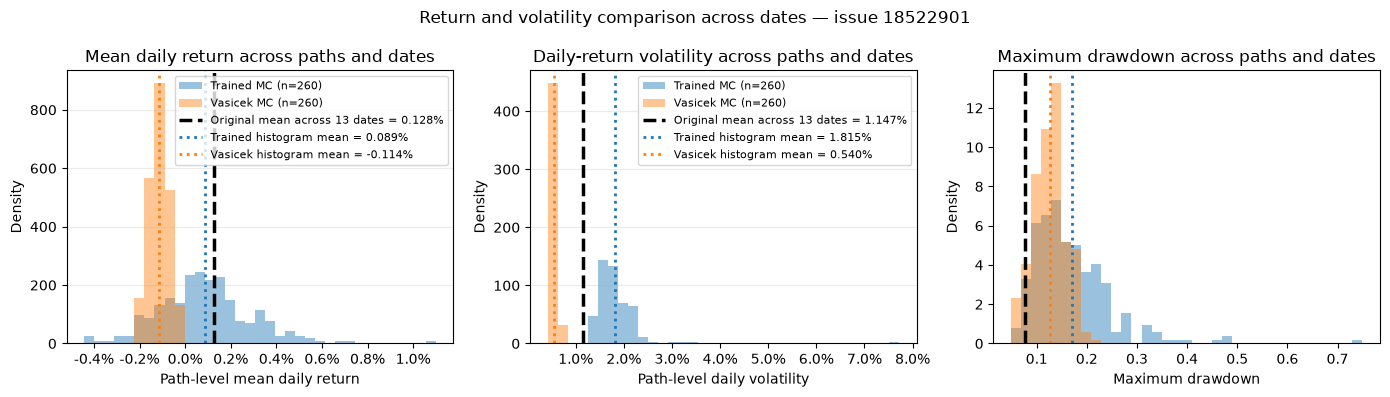

In [15]:
aggregate_colors = {
    'original': 'black', 'trained': 'tab:blue', 'vasicek': 'tab:orange'
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.ravel()

aggregate_mean_edges = shared_histogram_edges(
    issue_original_mean_returns, issue_trained_mean_returns,
    issue_vasicek_mean_returns, bins=35,
)
for values, color, label in [
    (issue_trained_mean_returns, aggregate_colors['trained'], 'Trained MC'),
    (issue_vasicek_mean_returns, aggregate_colors['vasicek'], 'Vasicek MC'),
]:
    axes[0].hist(values, bins=aggregate_mean_edges, density=True, alpha=0.45, color=color, label=f'{label} (n={values.size})')
aggregate_original_mean_return = float(issue_original_mean_returns.mean())
axes[0].axvline(
    aggregate_original_mean_return, color=aggregate_colors['original'],
    linestyle='--', linewidth=2.5,
    label=f'Original mean across {issue_original_mean_returns.size} dates = {aggregate_original_mean_return:.3%}',
)
aggregate_trained_mean_return = float(issue_trained_mean_returns.mean())
aggregate_vasicek_mean_return = float(issue_vasicek_mean_returns.mean())
axes[0].axvline(aggregate_trained_mean_return, color=aggregate_colors['trained'], linestyle=':', linewidth=2, label=f'Trained histogram mean = {aggregate_trained_mean_return:.3%}')
axes[0].axvline(aggregate_vasicek_mean_return, color=aggregate_colors['vasicek'], linestyle=':', linewidth=2, label=f'Vasicek histogram mean = {aggregate_vasicek_mean_return:.3%}')
axes[0].set(title='Mean daily return across paths and dates', xlabel='Path-level mean daily return', ylabel='Density')



aggregate_path_volatility_edges = shared_histogram_edges(
    issue_original_path_volatilities, issue_trained_path_volatilities,
    issue_vasicek_path_volatilities, bins=35,
)
for values, color, label in [
    (issue_trained_path_volatilities, aggregate_colors['trained'], 'Trained MC'),
    (issue_vasicek_path_volatilities, aggregate_colors['vasicek'], 'Vasicek MC'),
]:
    axes[1].hist(values, bins=aggregate_path_volatility_edges, density=True, alpha=0.45, color=color, label=f'{label} (n={values.size})')
aggregate_original_volatility = float(issue_original_path_volatilities.mean())
aggregate_trained_volatility = float(issue_trained_path_volatilities.mean())
aggregate_vasicek_volatility = float(issue_vasicek_path_volatilities.mean())
axes[1].axvline(aggregate_original_volatility, color=aggregate_colors['original'], linestyle='--', linewidth=2.5, label=f'Original mean across {issue_original_path_volatilities.size} dates = {aggregate_original_volatility:.3%}')
axes[1].axvline(aggregate_trained_volatility, color=aggregate_colors['trained'], linestyle=':', linewidth=2, label=f'Trained histogram mean = {aggregate_trained_volatility:.3%}')
axes[1].axvline(aggregate_vasicek_volatility, color=aggregate_colors['vasicek'], linestyle=':', linewidth=2, label=f'Vasicek histogram mean = {aggregate_vasicek_volatility:.3%}')
axes[1].set(title='Daily-return volatility across paths and dates', xlabel='Path-level daily volatility', ylabel='Density')



aggregate_drawdown_edges = shared_histogram_edges(
    issue_original_maximum_drawdowns, issue_trained_maximum_drawdowns,
    issue_vasicek_maximum_drawdowns, bins=35,
)
axes[2].hist(issue_trained_maximum_drawdowns, bins=aggregate_drawdown_edges, density=True, alpha=0.45, color='tab:blue', label=f'Trained MC (n={issue_trained_maximum_drawdowns.size})')
axes[2].hist(issue_vasicek_maximum_drawdowns, bins=aggregate_drawdown_edges, density=True, alpha=0.45, color='tab:orange', label=f'Vasicek MC (n={issue_vasicek_maximum_drawdowns.size})')
aggregate_original_drawdown = float(issue_original_maximum_drawdowns.mean())
aggregate_trained_drawdown = float(issue_trained_maximum_drawdowns.mean())
aggregate_vasicek_drawdown = float(issue_vasicek_maximum_drawdowns.mean())
axes[2].axvline(aggregate_original_drawdown, color='black', linestyle='--', linewidth=2.5, label=f'Original mean across {issue_original_maximum_drawdowns.size} dates = {aggregate_original_drawdown:.3%}')
axes[2].axvline(aggregate_trained_drawdown, color='tab:blue', linestyle=':', linewidth=2, label=f'Trained histogram mean = {aggregate_trained_drawdown:.3%}')
axes[2].axvline(aggregate_vasicek_drawdown, color='tab:orange', linestyle=':', linewidth=2, label=f'Vasicek histogram mean = {aggregate_vasicek_drawdown:.3%}')
axes[2].set(title='Maximum drawdown across paths and dates', xlabel='Maximum drawdown', ylabel='Density')


for ax in axes[:2]:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1%}'))
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle(f'Return and volatility comparison across dates — issue {AGGREGATE_RETURN_ISSUE_ID}')
fig.tight_layout()
plt.show()


# Across-issue distributions of return mean, volatility, and maximum drawdown

For every issue ID, this section produces one aggregated mean daily return, path volatility, and maximum drawdown for each source. The panels show the distributions of those issue-level values for original, trained, and Vasicek paths. Original paths are counted once per valid base sample/date, while trained and Vasicek paths retain all valid MC realizations.

In [16]:
across_issue_records = []
for current_issue_id in sorted({str(sample['issue_id']) for sample in loaded_samples['samples']}):
    current_valid_samples = [
        sample for sample in loaded_samples['samples']
        if str(sample['issue_id']) == current_issue_id and sample['is_valid']
    ]
    if not current_valid_samples:
        continue

    # Use each original future once for every base sample/date represented
    # among the valid MC paths.
    original_by_base_id = {}
    for sample in current_valid_samples:
        original_by_base_id.setdefault(sample['base_sample_id'], sample['original_price'])

    current_original_returns = [
        simple_daily_returns(prices) for prices in original_by_base_id.values()
    ]
    current_trained_returns = [
        simple_daily_returns(sample['synthetic_path']) for sample in current_valid_samples
    ]
    current_vasicek_returns = [
        simple_daily_returns(sample['random_synthetic']) for sample in current_valid_samples
    ]

    original_mean = float(np.mean([returns.mean() for returns in current_original_returns]))
    trained_mean = float(np.mean([returns.mean() for returns in current_trained_returns]))
    vasicek_mean = float(np.mean([returns.mean() for returns in current_vasicek_returns]))
    original_volatility = float(np.mean([returns.std(ddof=0) for returns in current_original_returns]))
    trained_volatility = float(np.mean([returns.std(ddof=0) for returns in current_trained_returns]))
    vasicek_volatility = float(np.mean([returns.std(ddof=0) for returns in current_vasicek_returns]))
    original_drawdown = float(np.mean([maximum_drawdown(prices) for prices in original_by_base_id.values()]))
    trained_drawdown = float(np.mean([maximum_drawdown(sample['synthetic_path']) for sample in current_valid_samples]))
    vasicek_drawdown = float(np.mean([maximum_drawdown(sample['random_synthetic']) for sample in current_valid_samples]))
    original_variance = float(np.mean([returns.var(ddof=0) for returns in current_original_returns]))
    trained_variance = float(np.mean([returns.var(ddof=0) for returns in current_trained_returns]))
    vasicek_variance = float(np.mean([returns.var(ddof=0) for returns in current_vasicek_returns]))

    across_issue_records.append({
        'issue_id': current_issue_id,
        'date_count': len(original_by_base_id),
        'valid_mc_path_count': len(current_valid_samples),
        'original_mean_return': original_mean,
        'trained_mean_return': trained_mean,
        'vasicek_mean_return': vasicek_mean,
        'original_return_volatility': original_volatility,
        'trained_return_volatility': trained_volatility,
        'vasicek_return_volatility': vasicek_volatility,
        'original_maximum_drawdown': original_drawdown,
        'trained_maximum_drawdown': trained_drawdown,
        'vasicek_maximum_drawdown': vasicek_drawdown,
        'original_return_variance': original_variance,
        'trained_return_variance': trained_variance,
        'vasicek_return_variance': vasicek_variance,
    })

across_issue_return_metrics = pd.DataFrame(across_issue_records)
if across_issue_return_metrics.empty:
    raise ValueError('No issue IDs have valid paths for the across-issue comparison')

display(across_issue_return_metrics.head())
print(f'Issue IDs included: {len(across_issue_return_metrics)}')


,issue_id,date_count,valid_mc_path_count,original_mean_return,trained_mean_return,vasicek_mean_return,original_return_volatility,trained_return_volatility,vasicek_return_volatility,original_maximum_drawdown,trained_maximum_drawdown,vasicek_maximum_drawdown,original_return_variance,trained_return_variance,vasicek_return_variance
0,00170601,12,240,0.000415,0.000507,-0.000170,0.018141,0.016574,0.004811,0.152499,0.159568,0.061802,0.000331,0.000373,0.000024
1,00549201,12,240,0.001576,0.000629,-0.000659,0.010165,0.013970,0.004139,0.059939,0.130223,0.084358,0.000106,0.000204,0.000018
2,00591801,13,260,0.000860,0.000599,-0.000658,0.011121,0.013607,0.004112,0.079429,0.132413,0.082908,0.000127,0.000196,0.000017
3,00694601,12,240,0.000668,0.001360,0.000245,0.017588,0.024121,0.007584,0.160391,0.204557,0.082503,0.000314,0.000716,0.000063
4,00792201,12,239,-0.000211,0.001592,0.001267,0.023045,0.029363,0.009577,0.247425,0.237167,0.068374,0.000535,0.001055,0.000096


Issue IDs included: 41


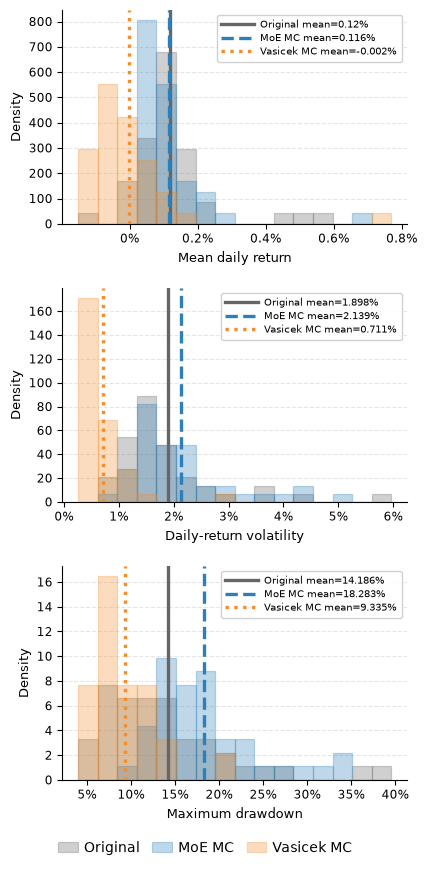

In [17]:
# Publication layout: one-column width with vertically stacked panels.
fig, axes = plt.subplots(3, 1, figsize=(4.2, 8.8))
across_issue_histogram_specs = [
    (
        axes[0],
        'original_mean_return', 'trained_mean_return', 'vasicek_mean_return',
        'Mean Daily Return Across Stocks', 'Mean daily return',
    ),
    (
        axes[1],
        'original_return_volatility', 'trained_return_volatility',
        'vasicek_return_volatility',
        'Daily-Return Volatility Across Stocks', 'Daily-return volatility',
    ),
    (
        axes[2],
        'original_maximum_drawdown', 'trained_maximum_drawdown',
        'vasicek_maximum_drawdown',
        'Maximum Drawdown Across Stocks', 'Maximum drawdown',
    ),
]
source_styles = [
    ('Original', '#666666', 'original', '-'),
    ('MoE MC', '#2C7FB8', 'trained', '--'),
    ('Vasicek MC', '#F28E2B', 'vasicek', ':'),
]

def compact_percent(value, decimals=2):
    """Format percentages without redundant trailing zeros."""
    number = f'{100.0 * value:.{decimals}f}'.rstrip('0').rstrip('.')
    return f'{number}%'

from matplotlib.lines import Line2D

for ax, original_column, trained_column, vasicek_column, title, xlabel in across_issue_histogram_specs:
    values_by_source = {
        'original': across_issue_return_metrics[original_column].to_numpy(),
        'trained': across_issue_return_metrics[trained_column].to_numpy(),
        'vasicek': across_issue_return_metrics[vasicek_column].to_numpy(),
    }
    edges = shared_histogram_edges(*values_by_source.values(), bins=16)
    for label, color, source, _ in source_styles:
        ax.hist(
            values_by_source[source], bins=edges, density=True, alpha=0.30,
            color=color, edgecolor=color, linewidth=0.9,
            label='_nolegend_', zorder=2,
        )

    mean_handles = []
    for label, color, source, mean_linestyle in source_styles:
        source_mean = float(values_by_source[source].mean())
        mean_line = ax.axvline(
            source_mean, color=color, linestyle=mean_linestyle,
            linewidth=2.4, zorder=5,
        )
        mean_handles.append(Line2D(
            [0], [0], color=color, linestyle=mean_linestyle, linewidth=2.4,
            label=f'{label} mean={compact_percent(source_mean, decimals=3)}',
        ))
    #ax.set_title(title, fontsize=10.5, fontweight='semibold', pad=7)
    ax.set_xlabel(xlabel, fontsize=9.5)
    ax.set_ylabel('Density', fontsize=9.5)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda value, _: compact_percent(value))
    )
    ax.tick_params(axis='both', which='major', labelsize=8.5)
    ax.grid(axis='y', linestyle='--', color='#B8B8B8', linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(
        handles=mean_handles,
        fontsize=7.3, frameon=True, framealpha=0.90, edgecolor='#CCCCCC',
        ncol=1, loc='upper right', borderpad=0.45, labelspacing=0.3,
        handlelength=3.2, handletextpad=0.6,
    )

from matplotlib.patches import Patch
bar_color_handles = [
    Patch(
        facecolor=color, edgecolor=color, linewidth=0.9, alpha=0.30,
        label=label,
    )
    for label, color, _, _ in source_styles
]
fig.legend(
    handles=bar_color_handles, title='', ncol=3,
    loc='lower center', bbox_to_anchor=(0.5, 0.005),
    fontsize=10, title_fontsize=8.5, frameon=False,
    handlelength=1.4, handletextpad=0.45, columnspacing=0.9,
)
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.105, top=0.98, hspace=0.3)

from pathlib import Path
publication_output_dir = Path.cwd().resolve()
across_issue_figure_png = publication_output_dir / 'across_issue_path_metric_histograms.png'
across_issue_figure_pdf = publication_output_dir / 'across_issue_path_metric_histograms.pdf'
fig.savefig(across_issue_figure_png, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


# Paired hypothesis tests of issue-level errors

For each issue ID, absolute Neural SDE and Vasicek errors are computed relative to the same original metric. A one-sided paired Wilcoxon signed-rank test is then applied separately to mean daily return, daily-return variance, and maximum drawdown. The null hypothesis is that the two models have the same error; the directional alternative is that the Neural SDE error is smaller. Positive error reductions (`Vasicek error − Neural SDE error`) favor the Neural SDE.

In [18]:
HYPOTHESIS_TEST_ALPHA = 0.05
from scipy import stats as scipy_stats

def paired_model_error_test(frame, metric, original_column, trained_column, vasicek_column):
    """One-sided paired Wilcoxon test of Neural SDE versus Vasicek errors."""
    values = frame[[original_column, trained_column, vasicek_column]].dropna()
    original = values[original_column].to_numpy(dtype=float)
    trained_error = np.abs(original - values[trained_column].to_numpy(dtype=float))
    vasicek_error = np.abs(original - values[vasicek_column].to_numpy(dtype=float))
    paired_difference = trained_error - vasicek_error

    if np.allclose(paired_difference, 0.0):
        test_statistic, p_value = 0.0, 1.0
    else:
        test_result = scipy_stats.wilcoxon(
            trained_error, vasicek_error, alternative='less',
            zero_method='wilcox', method='auto',
        )
        test_statistic = float(test_result.statistic)
        p_value = float(test_result.pvalue)

    mean_reduction = float(np.mean(vasicek_error - trained_error))
    median_reduction = float(np.median(vasicek_error - trained_error))
    return {
        'metric': metric,
        'issue_count': len(values),
        'neural_sde_mean_abs_error': float(trained_error.mean()),
        'vasicek_mean_abs_error': float(vasicek_error.mean()),
        'neural_sde_median_abs_error': float(np.median(trained_error)),
        'vasicek_median_abs_error': float(np.median(vasicek_error)),
        'mean_error_reduction_vas_minus_nsde': mean_reduction,
        'median_error_reduction_vas_minus_nsde': median_reduction,
        'wilcoxon_statistic': test_statistic,
        'one_sided_p_value': p_value,
        'decision_at_0.05': (
            'Reject H0: Neural SDE has smaller error'
            if p_value < HYPOTHESIS_TEST_ALPHA
            else 'Fail to reject H0'
        ),
    }

issue_level_error_tests = pd.DataFrame([
    paired_model_error_test(
        across_issue_return_metrics,
        metric='Mean daily return',
        original_column='original_mean_return',
        trained_column='trained_mean_return',
        vasicek_column='vasicek_mean_return',
    ),
    paired_model_error_test(
        across_issue_return_metrics,
        metric='Daily-return variance',
        original_column='original_return_variance',
        trained_column='trained_return_variance',
        vasicek_column='vasicek_return_variance',
    ),
    paired_model_error_test(
        across_issue_return_metrics,
        metric='Maximum drawdown',
        original_column='original_maximum_drawdown',
        trained_column='trained_maximum_drawdown',
        vasicek_column='vasicek_maximum_drawdown',
    ),
])

print('Paired one-sided Wilcoxon signed-rank tests')
print('H0: Neural SDE and Vasicek have the same absolute issue-level error.')
print('H1: Neural SDE has smaller absolute issue-level error than Vasicek.')
print(f'alpha = {HYPOTHESIS_TEST_ALPHA:.2f}\n')
print(issue_level_error_tests.to_string(index=False))
display(
    issue_level_error_tests.style.format({
        'neural_sde_mean_abs_error': '{:.6g}',
        'vasicek_mean_abs_error': '{:.6g}',
        'neural_sde_median_abs_error': '{:.6g}',
        'vasicek_median_abs_error': '{:.6g}',
        'mean_error_reduction_vas_minus_nsde': '{:.6g}',
        'median_error_reduction_vas_minus_nsde': '{:.6g}',
        'wilcoxon_statistic': '{:.3f}',
        'one_sided_p_value': '{:.6g}',
    })
)


Paired one-sided Wilcoxon signed-rank tests
H0: Neural SDE and Vasicek have the same absolute issue-level error.
H1: Neural SDE has smaller absolute issue-level error than Vasicek.
alpha = 0.05

               metric  issue_count  neural_sde_mean_abs_error  vasicek_mean_abs_error  neural_sde_median_abs_error  vasicek_median_abs_error  mean_error_reduction_vas_minus_nsde  median_error_reduction_vas_minus_nsde  wilcoxon_statistic  one_sided_p_value                        decision_at_0.05
    Mean daily return           41                   0.001047                0.001875                     0.000556                  0.001518                             0.000827                               0.000932               118.0           0.000009 Reject H0: Neural SDE has smaller error
Daily-return variance           41                   0.000318                0.000439                     0.000162                  0.000222                             0.000121                               0.000

,metric,issue_count,neural_sde_mean_abs_error,vasicek_mean_abs_error,neural_sde_median_abs_error,vasicek_median_abs_error,mean_error_reduction_vas_minus_nsde,median_error_reduction_vas_minus_nsde,wilcoxon_statistic,one_sided_p_value,decision_at_0.05
0,Mean daily return,41,0.00104721,0.00187464,0.000556359,0.00151839,0.000827434,0.000931512,118.000,8.50263e-06,Reject H0: Neural SDE has smaller error
1,Daily-return variance,41,0.000318253,0.000438934,0.000161815,0.000222458,0.000120681,4.24019e-05,263.000,0.0146981,Reject H0: Neural SDE has smaller error
2,Maximum drawdown,41,0.0521503,0.0609618,0.0498619,0.0468568,0.0088115,-0.0152364,400.000,0.350222,Fail to reject H0
